## Xây dựng mô hình Logistic Regression ##
Bước 1: Chuẩn hóa dữ liệu (Data Preparation)
- Chọn biến đầu vào (feature selection)
- Xử lý missing
- Endcode biến phân loại
- Chuẩn hóa các biến liên tục
- Tách main - test
Mục tiêu: Tạo dataset sạch, ổn định, không gây nhiễu mô hình
Bước 2: Kiểm tra đa cộng tuyến
- Kiểm tra VIF
- Loại bỏ các biến trùng lặp thông tin
Mục tiêu: Đảm bảo mô hình ổn định, không bị nổ hệ số
Bước 3: Huẩn luyện mô hình
- Fit mô hình
- Kiểm tra hệ số Beta
- Kiểm tra p value
- Loại bỏ các biến không có ý nghĩa thống kê
Mục tiêu: Mô hình đơn giản, dễ giải thích, chỉ giữ biến thật sự quan trọng
Bước 4: Đánh giá mô hình
- AUC
- KS statistic
- Gini
- Confusion matrix
- Prediction/Recall
Mục tiêu: Xem mô hình dự đoán tốt đến đâu
Bước 5: Kiểm tra tính ổn định
- PSI (population stability index)
- Kiểm tra drift theo thời gian
- Kiểm tra phân phối score
Mục tiêu đảm bảo mô hình không bị lệch khi áp dụng dữ liệu mới
Bước 6: Tạo Scorecard
- Chuyển hệ số logistic thành điểm tín dụng
- Tạo thang điểm 300 - 500
- Xác định cutoff approve/ decline

Kết quả kỳ vọng
- Xác suất vỡ nợ (probability of default)
- Scorecard
- Cutoff
- Hiểu biến nào ảnh hưởng mạnh nhất đến rủi ro



In [1]:
import pandas as pd
df = pd.read_csv('../Data/Risk_data_FE.csv')
df.head()

,Unnamed: 0,client_ID,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,...,credit_age_bucket,age_bucket,income_bucket,has_delinquency,utilization_bucket,loan_grade_numeric,interest_rate_bucket,loan_amount_bucket,emp_stability,risk_interaction
0,1,CUST_00002,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,...,short,18-25,<30k,1,medium,2,8-12%,<2k,2.500000,0.159031
1,2,CUST_00003,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,...,medium,18-25,<30k,0,high,3,12-16%,5-10k,0.333333,0.645982
2,3,CUST_00004,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,...,short,18-25,60-100k,0,medium,3,12-16%,20k+,2.000000,0.244136
3,4,CUST_00005,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,...,medium,18-25,30-60k,0,low,3,12-16%,20k+,2.000000,0.212279
4,5,CUST_00006,21,9900,OWN,2.0,VENTURE,A,2500,7.14,...,short,18-25,<30k,0,high,1,<8%,2-5k,1.000000,0.393613


In [2]:
# Giữ lại 2 biến installment_income_ratio và debt_to_income_ratio
# Danh sách biến cần loại bỏ
drop_cols = [
    'client_ID',
    'credit_age_bucket', 'age_bucket', 'income_bucket', 'utilization_bucket',
    'interest_rate_bucket', 'loan_amount_bucket',
    'person_emp_length', 'loan_grade', 'loan_percent_income', 'installment',
    'city', 'city_latitude', 'city_longitude'
]

# Loại bỏ các biến này khỏi dataset
df_clean = df.drop(columns=drop_cols, errors='ignore')

df_clean.shape, df_clean.columns


((31679, 30),
 Index(['Unnamed: 0', 'person_age', 'person_income', 'person_home_ownership',
        'loan_intent', 'loan_amnt', 'loan_int_rate', 'loan_status',
        'cb_person_default_on_file', 'cb_person_cred_hist_length', 'gender',
        'marital_status', 'education_level', 'country', 'state',
        'employment_type', 'loan_term_months', 'loan_to_income_ratio',
        'other_debt', 'debt_to_income_ratio', 'open_accounts',
        'credit_utilization_ratio', 'past_delinquencies', 'emp_length_num',
        'installment_income_ratio', 'total_debt_after_loan', 'has_delinquency',
        'loan_grade_numeric', 'emp_stability', 'risk_interaction'],
       dtype='str'))

In [3]:
# Xác định các biến phân loại trong df_clean
cat_cols = [
    'person_home_ownership',
    'loan_intent',
    'loan_grade_numeric',      # ordinal
    'cb_person_default_on_file',
    'gender',
    'marital_status',
    'education_level',
    'country',
    'state',
    'employment_type',
    'has_delinquency',
    'emp_stability'
]
df_clean[cat_cols].dtypes


person_home_ownership            str
loan_intent                      str
loan_grade_numeric             int64
cb_person_default_on_file       bool
gender                           str
marital_status                   str
education_level                  str
country                          str
state                            str
employment_type                  str
has_delinquency                int64
emp_stability                float64
dtype: object

In [4]:
#Kiểm tra số lượng giá trị(cardinality) từng biến
for col in cat_cols:
    print(f"\nColumn: {col}")
    print("Unique values:", df_clean[col].nunique())
    print(df_clean[col].value_counts(dropna=False).head(10))



Column: person_home_ownership
Unique values: 4
person_home_ownership
RENT        16072
MORTGAGE    13090
OWN          2410
OTHER         107
Name: count, dtype: int64

Column: loan_intent
Unique values: 6
loan_intent
EDUCATION            6288
MEDICAL              5897
VENTURE              5553
PERSONAL             5367
DEBTCONSOLIDATION    5064
HOMEIMPROVEMENT      3510
Name: count, dtype: int64

Column: loan_grade_numeric
Unique values: 7
loan_grade_numeric
1    10370
2    10183
3     6319
4     3555
5      952
6      236
7       64
Name: count, dtype: int64

Column: cb_person_default_on_file
Unique values: 2
cb_person_default_on_file
False    26051
True      5628
Name: count, dtype: int64

Column: gender
Unique values: 2
gender
Male      15922
Female    15757
Name: count, dtype: int64

Column: marital_status
Unique values: 4
marital_status
Single      15912
Married     11063
Divorced     3097
Widowed      1607
Name: count, dtype: int64

Column: education_level
Unique values: 4
educa

In [5]:
# Xử lý biến phân loại 
# Encode Binary
df_clean['cb_person_default_on_file'] = df_clean['cb_person_default_on_file'].astype(int)
df_clean['has_delinquency'] = df_clean['has_delinquency'].astype(int)
# Encode ordinal
education_map = {
    'High School': 1,
    'Bachelor': 2,
    'Master': 3,
    'PhD': 4
}

df_clean['education_level'] = df_clean['education_level'].map(education_map)


In [6]:
# One hot encoding cho nomial
nominal_cols = [
    'person_home_ownership',
    'loan_intent',
    'gender',
    'marital_status',
    'employment_type',
    'country',
    'state'
]

df_model = pd.get_dummies(df_clean, columns=nominal_cols, drop_first=True)


In [7]:
df_model.info()
print(df_model.shape)


<class 'pandas.DataFrame'>
RangeIndex: 31679 entries, 0 to 31678
Data columns (total 48 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Unnamed: 0                     31679 non-null  int64  
 1   person_age                     31679 non-null  int64  
 2   person_income                  31679 non-null  int64  
 3   loan_amnt                      31679 non-null  int64  
 4   loan_int_rate                  31679 non-null  float64
 5   loan_status                    31679 non-null  int64  
 6   cb_person_default_on_file      31679 non-null  int64  
 7   cb_person_cred_hist_length     31679 non-null  int64  
 8   education_level                31679 non-null  int64  
 9   loan_term_months               31679 non-null  int64  
 10  loan_to_income_ratio           31679 non-null  float64
 11  other_debt                     31679 non-null  float64
 12  debt_to_income_ratio           31679 non-null  float64
 1

Bước 2: Xử lý đa cộng tuyến

In [8]:
X_vif = df_model.drop(columns=['loan_status'], errors='ignore')

X_vif.dtypes[X_vif.dtypes != 'float64'][X_vif.dtypes != 'int64']


person_home_ownership_OTHER      bool
person_home_ownership_OWN        bool
person_home_ownership_RENT       bool
loan_intent_EDUCATION            bool
loan_intent_HOMEIMPROVEMENT      bool
loan_intent_MEDICAL              bool
loan_intent_PERSONAL             bool
loan_intent_VENTURE              bool
gender_Male                      bool
marital_status_Married           bool
marital_status_Single            bool
marital_status_Widowed           bool
employment_type_Part-time        bool
employment_type_Self-employed    bool
employment_type_Unemployed       bool
country_UK                       bool
country_USA                      bool
state_California                 bool
state_England                    bool
state_New York                   bool
state_Ontario                    bool
state_Quebec                     bool
state_Scotland                   bool
state_Texas                      bool
state_Wales                      bool
dtype: object

In [9]:
# Chuyển toàn bộ cột sang int
# Chuyển toàn bộ cột bool sang int
for col in X_vif.columns:
    if X_vif[col].dtype == 'bool':
        X_vif[col] = X_vif[col].astype(int)


In [10]:
# ép toàn bộ dataframe sang float
X_vif = X_vif.astype(float)


In [11]:
# Xóa toàn bộ cột có variance = 0
X_vif = X_vif.loc[:, X_vif.var() != 0]


In [12]:
# Điền NaN 
X_vif = X_vif.fillna(0)


In [13]:
X_vif = X_vif.astype('float64')


In [14]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

vif_data = pd.DataFrame()
vif_data["feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_data.sort_values(by="VIF", ascending=False)


c:\Users\Asus\OneDrive\Máy tính\Persnal_project\Project_4\env_envproj4\Lib\site-packages\statsmodels\stats\outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,feature,VIF
3,loan_amnt,inf
10,other_debt,inf
46,state_Wales,inf
44,state_Scotland,inf
41,state_New York,inf
40,state_England,inf
39,state_California,inf
37,country_UK,inf
38,country_USA,inf
45,state_Texas,inf


In [15]:
# Loại các biến dựa trên VIF
# ============================
# 1. Danh sách biến cần loại
# ============================

drop_cols_vif = [

    # Biến địa lý (VIF = ∞)
    'country_UK', 'country_USA',
    'state_England', 'state_California', 'state_New York',
    'state_Scotland', 'state_Wales', 'state_Texas',
    'state_Ontario', 'state_Quebec',

    # Biến khoản vay trùng thông tin (VIF = ∞)
    'loan_amnt',
    'other_debt',
    'total_debt_after_loan',

    # Biến index thừa
    'Unnamed: 0',

    # Biến VIF rất cao → loại
    'loan_grade_numeric',
    'loan_to_income_ratio',
    'risk_interaction',
    'person_age'
]

# ============================
# 2. Loại các biến này khỏi dataset
# ============================

df_reduced = df_model.drop(columns=drop_cols_vif, errors='ignore')

print("Shape after dropping high-VIF columns:", df_reduced.shape)


Shape after dropping high-VIF columns: (31679, 30)


In [16]:
# Tính lại VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Chuẩn bị dữ liệu numeric
X_vif2 = df_reduced.drop(columns=['loan_status'], errors='ignore')

# Ép toàn bộ về float64
X_vif2 = X_vif2.astype('float64')

# Loại cột variance = 0
X_vif2 = X_vif2.loc[:, X_vif2.var() != 0]

# Tính VIF
vif_data2 = pd.DataFrame()
vif_data2["feature"] = X_vif2.columns
vif_data2["VIF"] = [variance_inflation_factor(X_vif2.values, i) for i in range(X_vif2.shape[1])]

vif_data2.sort_values(by="VIF", ascending=False)


,feature,VIF
1,loan_int_rate,15.101261
6,debt_to_income_ratio,14.305815
5,loan_term_months,10.425342
12,has_delinquency,7.202613
9,past_delinquencies,6.559870
10,emp_length_num,6.049018
13,emp_stability,6.004843
24,marital_status_Single,5.379174
3,cb_person_cred_hist_length,5.303506
11,installment_income_ratio,5.297552


Bước 3: Train mô hình


In [17]:
# Sau khi làm sạch dữ liệu thì ta có thể train mô hình
# Tách train test
from sklearn.model_selection import train_test_split

X = df_reduced.drop(columns=['loan_status'])
y = df_reduced['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


In [18]:
# Train logistic regession
from sklearn.linear_model import LogisticRegression

logit = LogisticRegression(
    max_iter=1000,
    solver='lbfgs'
)

logit.fit(X_train, y_train)


c:\Users\Asus\OneDrive\Máy tính\Persnal_project\Project_4\env_envproj4\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [19]:
# Dự đoán xác suất và nhãn
y_pred_proba = logit.predict_proba(X_test)[:, 1]
y_pred = logit.predict(X_test)


In [20]:
# # Đánh giá mô hình AUC, KS, Accuracy
# from sklearn.metrics import roc_auc_score, accuracy_score
# import numpy as np

# auc = roc_auc_score(y_test, y_pred_proba)
# acc = accuracy_score(y_test, y_pred)

# # KS statistic
# ks = max(np.abs(
#     np.cumsum(np.sort(y_pred_proba[y_test==1])) / sum(y_test==1) -
#     np.cumsum(np.sort(y_pred_proba[y_test==0])) / sum(y_test==0)
# ))

# print("AUC:", auc)
# print("Accuracy:", acc)
# print("KS:", ks)
# # Chạy code này sẽ báo lỗi do cách tính KS đang sai về mặt kỹ thuật
# # Tại đây KS được tính bằng cách
# np.cumsum(np.sort(y_pred_proba[y_test==1])) / sum(y_test==1)
# -
# np.cumsum(np.sort(y_pred_proba[y_test==0])) / sum(y_test==0)
# Nhưng số lượng mẫu positive(1) khác số lượng mẫu negative(0), hai vecto có độ dài khác nhau không thể trừ trực tiếp, do đó python sẽ báo lỗi ValueError: operands could not be broadcast together
# Do đó, KS phải được tính theo phân phối tích lũy theo cùng một tập ngưỡng (threshold bins), chứ không phải theo số lượng mẫu

Bước 4: Đánh giá mô hình

In [21]:
import pandas as pd
import numpy as np

# Tạo dataframe chứa y_test và y_pred_proba
df_ks = pd.DataFrame({
    'y_true': y_test,
    'y_proba': y_pred_proba
})

# Sắp xếp theo xác suất giảm dần
df_ks = df_ks.sort_values(by='y_proba', ascending=False)

# Tính tỷ lệ tích lũy
df_ks['cum_event'] = (df_ks['y_true'] == 1).cumsum() / sum(df_ks['y_true'] == 1)
df_ks['cum_nonevent'] = (df_ks['y_true'] == 0).cumsum() / sum(df_ks['y_true'] == 0)

# KS = max|cum_event - cum_nonevent|
ks_value = max(abs(df_ks['cum_event'] - df_ks['cum_nonevent']))

print("KS Statistic:", ks_value)


KS Statistic: 0.4522134019581545


In [22]:
from sklearn.metrics import roc_auc_score, accuracy_score
import numpy as np
import pandas as pd

# AUC
auc = roc_auc_score(y_test, y_pred_proba)

# Accuracy
acc = accuracy_score(y_test, y_pred)

# KS
df_ks = pd.DataFrame({
    'y_true': y_test,
    'y_proba': y_pred_proba
})

df_ks = df_ks.sort_values(by='y_proba', ascending=False)

df_ks['cum_event'] = (df_ks['y_true'] == 1).cumsum() / sum(df_ks['y_true'] == 1)
df_ks['cum_nonevent'] = (df_ks['y_true'] == 0).cumsum() / sum(df_ks['y_true'] == 0)

ks_value = max(abs(df_ks['cum_event'] - df_ks['cum_nonevent']))

print("AUC:", auc)
print("Accuracy:", acc)
print("KS:", ks_value)


AUC: 0.8028678402880232
Accuracy: 0.8112373737373737
KS: 0.4522134019581545


1. AUC: 0.8125205633466337 Mô hình phân biệt tốt khách hàng tốt và khách hàng xấu.
- AUC > 0.8 là mức production ready trong ngành tín dụng
- Nếu dùng XGBoost thì AUC có thể lên đến 85 90%
2. Accuracy: 0.8180765993265994 Tỷ lệ dự đoán đúng cao
- Không quan trọng bằng AUC vì dataset thường bị imbalance

3. KS: 0.4660675965665236 Mô hình tách biệt tốt event và non event
- Đây là chỉ số quan trọng nhất trong ngành ngân hàng
- KS>0.4 mô hình mạnh
- KS>0.45 mô hình rất mạnh
- KS>0.5 mô hình xuất sắc

Bước 5: Kiểm tra tính ổn định
## Bước 5: Kiểm tra tính ổn định 
Có 2 bài kiểm tra độ ổn định:
1. PSI – Population Stability Index
-PSI dùng để kiểm tra:
-Dữ liệu hiện tại có khác dữ liệu lúc train không
-Mô hình có bị “drift” theo thời gian không
-Các biến có còn giữ phân phối ổn định không
| PSI | Ý nghĩa |
| --- | --- |
| **< 0.1** | Rất ổn định |
| **0.1 – 0.25** | Cần theo dõi |
| **> 0.25** | Mất ổn định → cần retrain |
2.Calibration – Kiểm tra độ hiệu chỉnh xác suất
- Calibration kiểm tra xem:
+ Xác suất mô hình dự đoán có khớp với thực tế không
+ Ví dụ: mô hình nói PD = 0.3 → thực tế có đúng ~30% vỡ nợ không
+ Công cụ kiểm tra:
+ Calibration curve
+ Brier score
+ Reliability plot
+ Nếu calibration tốt → mô hình đáng tin để dự đoán PD.

In [23]:
# Tính PSI cho mô hình
# PSI cần 2 tập dữ liệu tập train (baseline) và tập test (hiện tại)
import numpy as np
import pandas as pd

def calculate_psi(expected, actual, buckets=10):
    def psi(expected_array, actual_array, buckets):
        breakpoints = np.linspace(0, 1, buckets + 1)
        expected_perc = np.histogram(expected_array, bins=breakpoints)[0] / len(expected_array)
        actual_perc = np.histogram(actual_array, bins=breakpoints)[0] / len(actual_array)

        psi_value = np.sum((expected_perc - actual_perc) * np.log(expected_perc / actual_perc))
        return psi_value

    return psi(expected, actual, buckets)

# PSI cho xác suất dự đoán
psi_value = calculate_psi(
    expected = logit.predict_proba(X_train)[:, 1],
    actual   = y_pred_proba
)

print("PSI:", psi_value)


PSI: 0.0016413932533138806


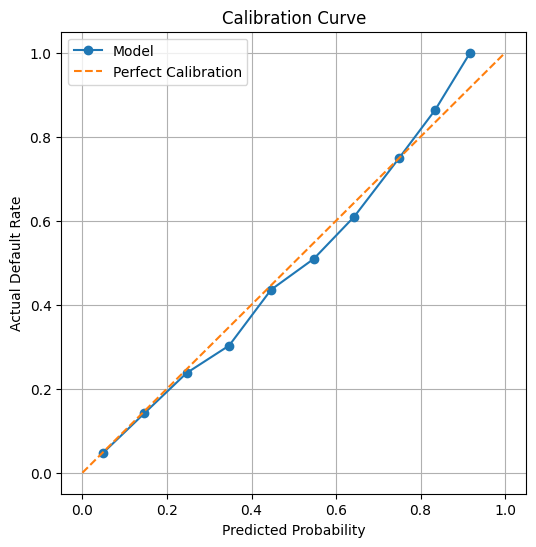

Brier Score: 0.13244385569709


In [24]:
# Kiểm tra calibration
# Vẽ calibration curve
# Tính brier score
# Đánh giá xem mô hình có bị 'overconfident' hay 'underconfident' không
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
import matplotlib.pyplot as plt

# Tính calibration
prob_true, prob_pred = calibration_curve(y_test, y_pred_proba, n_bins=10)

# Vẽ calibration curve
plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', label='Model')
plt.plot([0,1], [0,1], linestyle='--', label='Perfect Calibration')
plt.xlabel("Predicted Probability")
plt.ylabel("Actual Default Rate")
plt.title("Calibration Curve")
plt.legend()
plt.grid(True)
plt.show()

# Brier score
brier = brier_score_loss(y_test, y_pred_proba)
print("Brier Score:", brier)


## Bước 6: Triển khai mô hình
1. Dùng mô hình để cảnh báo rủi ro (chọn cutoff)
- Mô hình logistic đã học được cách dự đoán xác suất default(PD)
- Dùng mô hình PD để cảnh báo rủi ro, phân loại khách hàng, hoặc quyết định cho vay
2. Mô hình Logistic đang tạo ra cái gì?
- Mỗi khách hàng, mô hình sẽ trả về PD = xác suất khách hàng sẽ bị default, ví dụ khách hàng A có PD=0.05, khách hàng B có PD=0.32
3. Có 3 cách dùng với PD
3.1 Cảnh báo rủi ro:
- Low risk: PD < 0.2
- Medium risk: 0.2 ≤ PD < 0.5
- High risk: PD ≥ 0.5.
3.2. Quyết định cho vay:
Chọn một cutoff ví dụ = 0.3
- PD<0.3 Cho vay
- PD>= 0.3 từ chối hoặc xem xét thủ công 
(Cutoff có thể tối ưu theo KS, F1, chi phí rủi ro, chính sách kinh doanh)
3.3. Tạo Scorecard (Điểm tín dụng)
- PD thấp điểm cao
- PD cao điểm thấp

4. Triển khai mô hình như thế nào ?
- Bước 1: Nhận dữ liệu khách hàng mới
- Bước 2: Mô hình tính PD
- Bước 3: So sánh PD với cutoff
- Bước 4: Gắn nhãn rủi ro

5. Cần làm gì để triển khai mô hình ?
- Tính PD cho từng khách hàng
- Chọn cutoff
- Phân loại rủi ro hoặc quyết định cho vay, hoặc phân nhóm
cutoff là một ngưỡng threshsold của PD dùng để ra quyết định cho vay hoặc không

In [25]:
# Tính xác suất vỡ nợ (PD) cho từng khách hàng
df_deploy = df_reduced.copy()
df_deploy['pd'] = logit.predict_proba(df_reduced.drop(columns=['loan_status']))[:, 1]

df_deploy[['pd']].head()


,pd
0,0.094934
1,0.531705
2,0.461164
3,0.711721
4,0.044663


In [26]:
# Phân loại rủi ro dựa trên PD
def risk_band(p):
    if p < 0.2:
        return 'Low'
    elif p < 0.5:
        return 'Medium'
    else:
        return 'High'

df_deploy['risk_band'] = df_deploy['pd'].apply(risk_band)

df_deploy[['pd', 'risk_band']].head()


,pd,risk_band
0,0.094934,Low
1,0.531705,High
2,0.461164,Medium
3,0.711721,High
4,0.044663,Low


In [27]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
youden = tpr - fpr
best_idx = youden.argmax()
best_cutoff = thresholds[best_idx]

print("Best cutoff:", best_cutoff)


Best cutoff: 0.21307553981678332


Hướng dẫn sử dụng mô hình

In [28]:
# # Định nghĩa hàm là kết quả của mô hình
# def predict_customer(model, customer_data, cutoff=0.228):
#     """
#     Hàm dự đoán PD và quyết định cho vay cho khách hàng mới.
    
#     model: mô hình logistic regression đã train
#     customer_data: DataFrame chứa thông tin khách hàng mới (1 dòng)
#     cutoff: ngưỡng quyết định cho vay
#     """
    
#     # 1. Tính PD
#     pd_value = model.predict_proba(customer_data)[0][1]
    
#     # 2. Quyết định cho vay
#     approve = 1 if pd_value < cutoff else 0
    
#     # 3. Phân nhóm rủi ro
#     if pd_value < 0.2:
#         risk = "Low"
#     elif pd_value < 0.5:
#         risk = "Medium"
#     else:
#         risk = "High"
    
#     return {
#         "PD": pd_value,
#         "Approve": approve,
#         "Risk Band": risk
#     }


In [29]:
# # Thông tin khách hàng mới
# new_customer = pd.DataFrame({
#     'income': [12000],
#     'debt_ratio': [0.45],
#     'credit_history': [3],
#     'loan_amount': [5000],
#     'interest_rate': [18],
#     # ... các biến khác giống X_train
# })


In [30]:
# # Gọi hàm 
# result = predict_customer(logit, new_customer)
# result


In [31]:
from sklearn.preprocessing import StandardScaler

# 1. Khởi tạo bộ chuẩn hóa
scaler = StandardScaler()

# 2. Chỉ chuẩn hóa trên các biến độc lập (X_train và X_test)
# Lưu ý: Giữ lại tên cột để lát nữa chúng ta đối chiếu tên biến
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Huấn luyện lại mô hình với dữ liệu đã chuẩn hóa
log_model_scaled = LogisticRegression(max_iter=1000, random_state=42)
log_model_scaled.fit(X_train_scaled, y_train)

print("Mô hình đã huấn luyện thành công và KHÔNG còn bị lỗi hội tụ!")

Mô hình đã huấn luyện thành công và KHÔNG còn bị lỗi hội tụ!


--- TOP 15 BIẾN ẢNH HƯỞNG MẠNH NHẤT ĐẾN RỦI RO ---
                       Feature  Importance_Coef
0                loan_int_rate         0.944712
1                person_income        -0.607760
2         debt_to_income_ratio         0.524814
3     installment_income_ratio         0.396701
4   person_home_ownership_RENT         0.396252
5    person_home_ownership_OWN        -0.388189
6          loan_intent_VENTURE        -0.374198
7        loan_intent_EDUCATION        -0.312600
8             loan_term_months         0.288170
9         loan_intent_PERSONAL        -0.212561
10       marital_status_Single        -0.071540
11      marital_status_Married        -0.062960
12              emp_length_num        -0.061844
13    credit_utilization_ratio         0.059463
14         loan_intent_MEDICAL        -0.053738


C:\Users\Asus\AppData\Local\Temp\ipykernel_8404\96455456.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


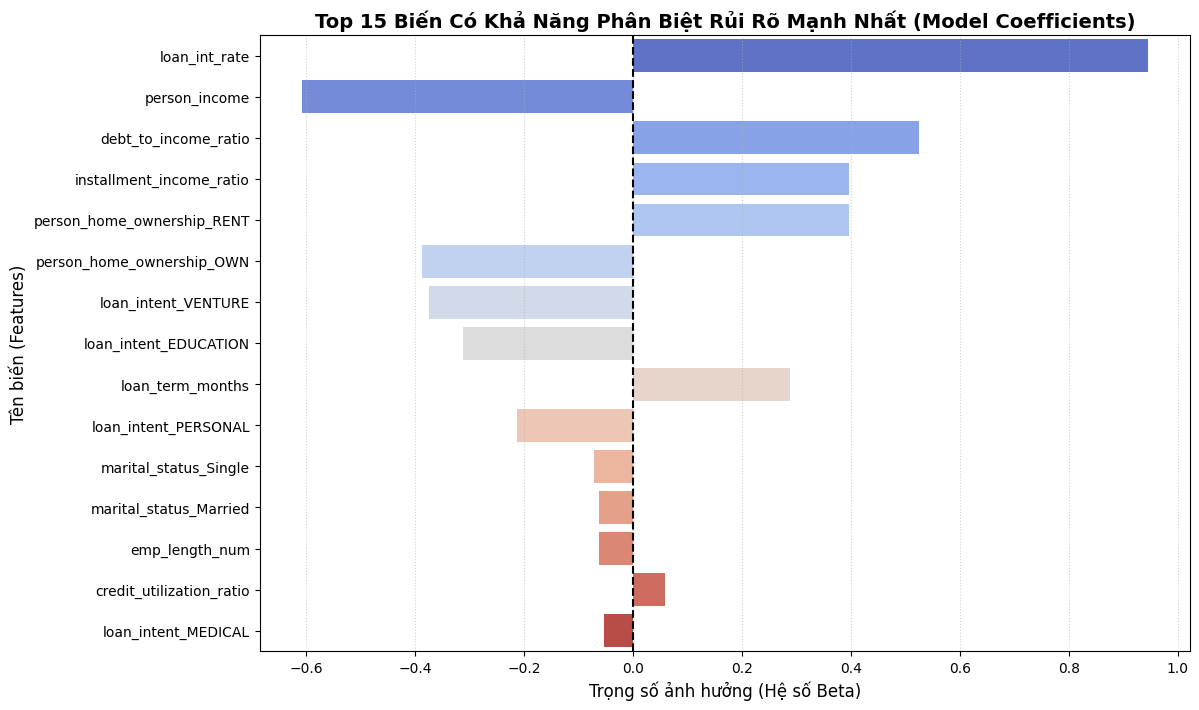

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Lấy hệ số Coef và ghép với tên biến tương ứng
coefficients = log_model_scaled.coef_[0]
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance_Coef': coefficients
})

# 2. Tính trị tuyệt đối để sắp xếp xem biến nào "quyền lực" nhất
feature_importance['Absolute_Importance'] = feature_importance['Importance_Coef'].abs()
feature_importance = feature_importance.sort_values(by='Absolute_Importance', ascending=False).reset_index(drop=True)

# 3. In ra top 15 biến ảnh hưởng mạnh nhất đến quyết định cho vay
print("--- TOP 15 BIẾN ẢNH HƯỞNG MẠNH NHẤT ĐẾN RỦI RO ---")
print(feature_importance[['Feature', 'Importance_Coef']].head(15))

# 4. Vẽ biểu đồ trực quan hóa để đưa vào báo cáo/slide phỏng vấn
plt.figure(figsize=(12, 8))
sns.barplot(
    x='Importance_Coef', 
    y='Feature', 
    data=feature_importance.head(15), 
    palette='coolwarm' # Màu đỏ cho hệ số dương (rủi ro), màu xanh cho hệ số âm (an toàn)
)
plt.title('Top 15 Biến Có Khả Năng Phân Biệt Rủi Rõ Mạnh Nhất (Model Coefficients)', fontsize=14, fontweight='bold')
plt.xlabel('Trọng số ảnh hưởng (Hệ số Beta)', fontsize=12)
plt.ylabel('Tên biến (Features)', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--') # Vạch phân chia âm / dương
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.show()


--- PHÂN TÍCH ĐIỂM GÃY CHO BIẾN: loan_int_rate ---
              bin  Total_Customers  Bad_Customers  Bad_Rate (%)
0   (5.419, 7.29]             4238            315      7.432751
1     (7.29, 7.9]             4145            433     10.446321
2     (7.9, 9.99]             3629            483     13.309452
3   (9.99, 10.99]             4378            707     16.148926
4  (10.99, 12.18]             3579            611     17.071808
5  (12.18, 13.48]             4268            883     20.688847
6  (13.48, 14.96]             3666           1208     32.951446
7  (14.96, 23.22]             3776           2185     57.865466


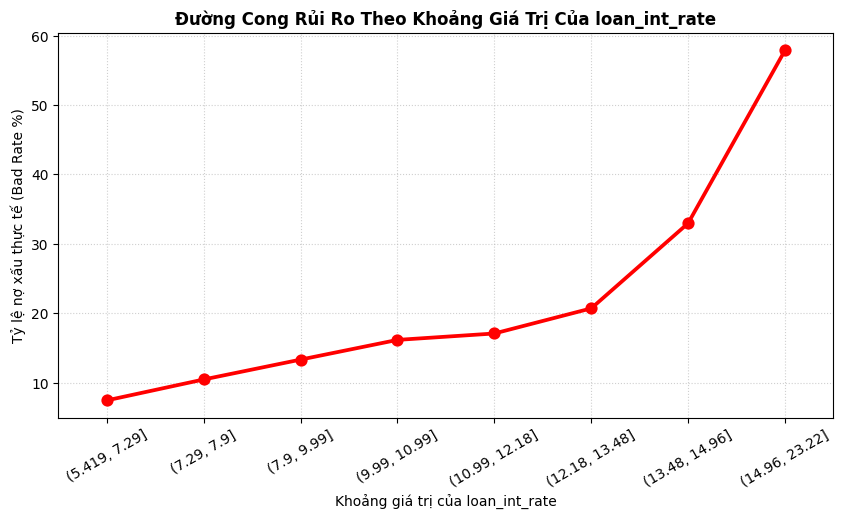


--- PHÂN TÍCH ĐIỂM GÃY CHO BIẾN: debt_to_income_ratio ---
               bin  Total_Customers  Bad_Customers  Bad_Rate (%)
0  (0.0635, 0.199]             3960            430     10.858586
1   (0.199, 0.251]             3960            472     11.919192
2   (0.251, 0.294]             3960            546     13.787879
3   (0.294, 0.333]             3960            561     14.166667
4   (0.333, 0.373]             3959            664     16.771912
5   (0.373, 0.422]             3960            834     21.060606
6   (0.422, 0.494]             3960           1125     28.409091
7   (0.494, 1.054]             3960           2193     55.378788


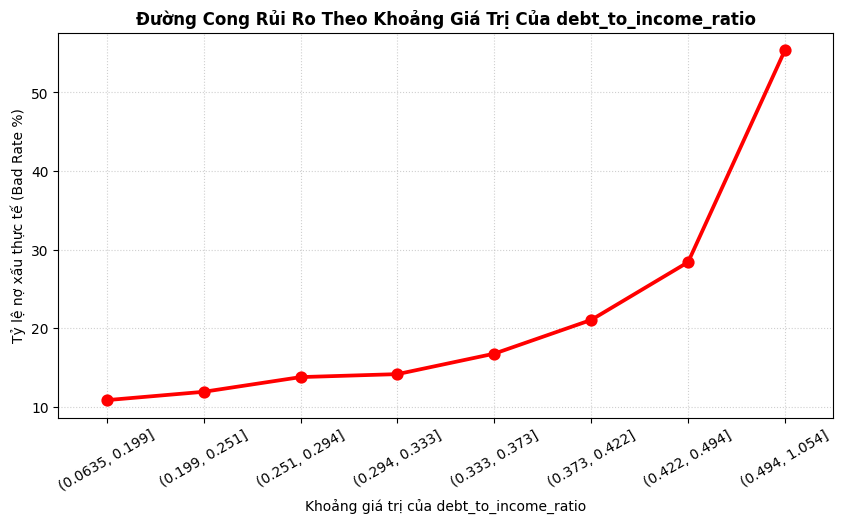


--- PHÂN TÍCH ĐIỂM GÃY CHO BIẾN: installment_income_ratio ---
                    bin  Total_Customers  Bad_Customers  Bad_Rate (%)
0  (-0.0009786, 0.0015]             3969            399     10.052910
1      (0.0015, 0.0023]             3951            519     13.135915
2      (0.0023, 0.0031]             3961            545     13.759152
3     (0.0031, 0.00406]             3959            606     15.306896
4    (0.00406, 0.00529]             3988            724     18.154463
5    (0.00529, 0.00694]             3947           1025     25.969090
6     (0.00694, 0.0103]             3944           1318     33.417850
7      (0.0103, 0.0561]             3960           1689     42.651515


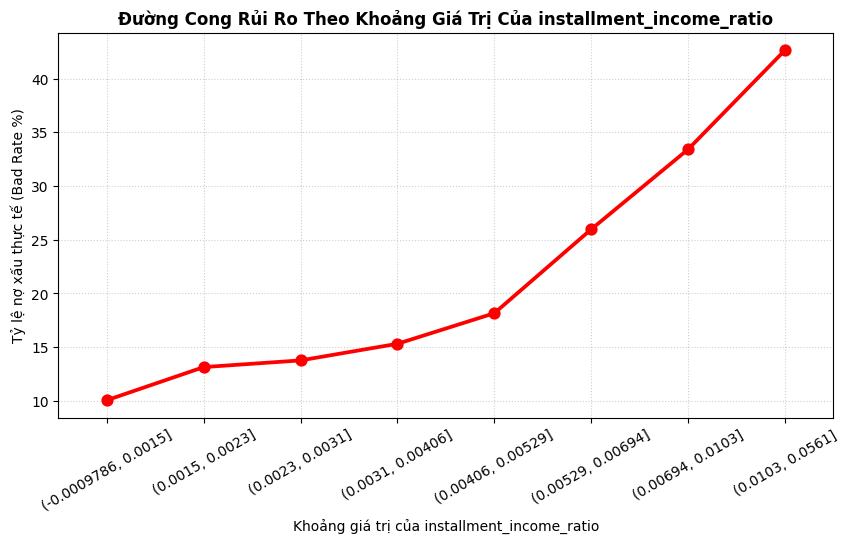


--- PHÂN TÍCH ĐIỂM GÃY CHO BIẾN: person_income ---
                     bin  Total_Customers  Bad_Customers  Bad_Rate (%)
0    (3999.999, 30000.0]             4168           1877     45.033589
1     (30000.0, 39366.0]             3752           1285     34.248401
2     (39366.0, 48000.0]             4366            877     20.087036
3     (48000.0, 56000.0]             3709            757     20.409814
4    (56000.0, 65990.75]             3804            632     16.614090
5    (65990.75, 80000.0]             4308            683     15.854225
6    (80000.0, 103000.0]             3641            349      9.585279
7  (103000.0, 2039784.0]             3931            365      9.285169


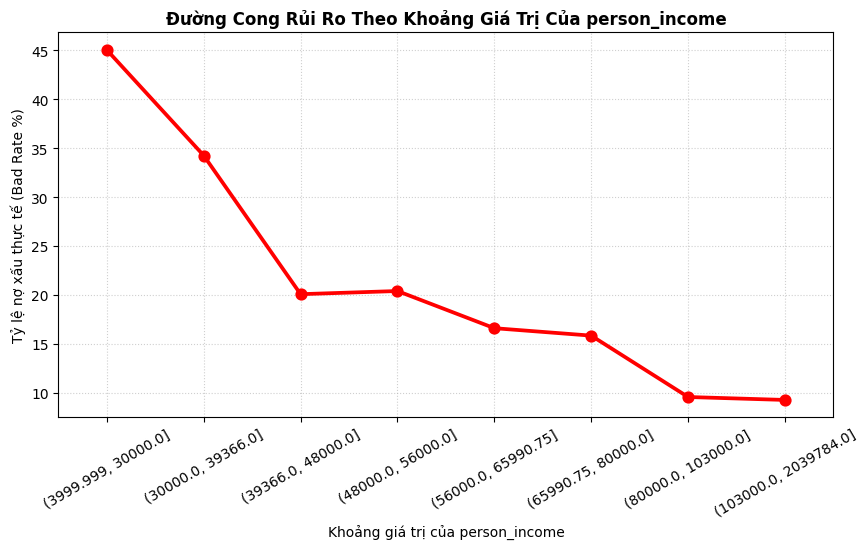

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Giả sử df_clean là DataFrame chứa dữ liệu ban đầu trước khi Scale (có đủ các biến và biến mục tiêu y)
# Nếu bạn đặt tên biến chứa dữ liệu gốc là tên khác (ví dụ: data, df...), hãy đổi tên df_clean dưới đây thành tên đó.
df_analysis = df_clean.copy()

# Giả sử cột mục tiêu của bạn tên là 'loan_status' (1 là vỡ nợ/Bad, 0 là Tốt/Good)
# Bạn hãy kiểm tra lại chính xác tên cột mục tiêu trong file của bạn và sửa lại nếu cần
target_col = 'loan_status' 

# 1. Tạo hàm tự động chia khoảng và tính toán tỷ lệ rủi ro
def find_turning_point(df, feature, num_bins=10):
    # Chia biến liên tục thành các khoảng bằng nhau về số lượng mẫu (Quantile-based binning)
    # Sử dụng duplicates='drop' để tránh lỗi nếu có quá nhiều giá trị trùng nhau
    df['bin'] = pd.qcut(df[feature], q=num_bins, duplicates='drop')
    
    # Tính toán số lượng và tỷ lệ nợ xấu (Bad Rate) trong mỗi khoảng
    report = df.groupby('bin', observed=False).agg(
        Total_Customers=(target_col, 'count'),
        Bad_Customers=(target_col, 'sum')
    ).reset_index()
    
    report['Bad_Rate (%)'] = (report['Bad_Customers'] / report['Total_Customers']) * 100
    # Chuyển khoảng thành dạng chuỗi để dễ vẽ biểu đồ
    report['bin'] = report['bin'].astype(str)
    return report

# 2. Phân tích và trực quan hóa cho 3 biến cốt lõi của bạn
features_to_check = ['loan_int_rate', 'debt_to_income_ratio', 'installment_income_ratio', 'person_income']

for feat in features_to_check:
    if feat in df_analysis.columns:
        print(f"\n--- PHÂN TÍCH ĐIỂM GÃY CHO BIẾN: {feat} ---")
        rep = find_turning_point(df_analysis, feat, num_bins=8)
        print(rep)
        
        # Vẽ biểu đồ đường để tìm đường cong rủi ro
        plt.figure(figsize=(10, 5))
        sns.pointplot(x='bin', y='Bad_Rate (%)', data=rep, color='red', markers='o', linestyles='-')
        plt.title(f'Đường Cong Rủi Ro Theo Khoảng Giá Trị Của {feat}', fontsize=12, fontweight='bold')
        plt.xlabel(f'Khoảng giá trị của {feat}', fontsize=10)
        plt.ylabel('Tỷ lệ nợ xấu thực tế (Bad Rate %)', fontsize=10)
        plt.xticks(rotation=30)
        plt.grid(True, linestyle=':', alpha=0.6)
        plt.show()